In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def generate_behavioral_data(n_samples=5000):
    data = []

    for i in range(n_samples):
        is_bot = random.random() < 0.3  # 30% are fake/bots

        if is_bot:
            # BOT BEHAVIOR: High regularity, bursty, repetitive text
            timing_regularity = random.uniform(0.8, 1.0) # Very regular
            engagement_burst = random.uniform(0.7, 1.0)  # High burst
            linguistic_consistency = random.uniform(0.9, 1.0) # Highly repetitive
            network_overlap = random.uniform(0.6, 1.0) # High coordination

            # Simulated raw metrics
            posts_per_hour = random.randint(50, 200)
            avg_time_diff = random.uniform(0.1, 2.0) # Constant small gaps

        else:
            # ORGANIC BEHAVIOR: Low regularity, natural flow, unique text
            timing_regularity = random.uniform(0.1, 0.4)
            engagement_burst = random.uniform(0.1, 0.3)
            linguistic_consistency = random.uniform(0.2, 0.5)
            network_overlap = random.uniform(0.0, 0.3)

            # Simulated raw metrics
            posts_per_hour = random.randint(1, 15)
            avg_time_diff = random.uniform(30.0, 300.0) # Gaps vary wildly

        data.append({
            'user_id': f'user_{i}',
            'timing_regularity': timing_regularity,
            'burst_pattern_score': engagement_burst,
            'linguistic_entropy': 1 - linguistic_consistency, # Low entropy = fake
            'network_coordination_index': network_overlap,
            'posts_per_hour': posts_per_hour,
            'avg_inter_arrival_time': avg_time_diff,
            'is_fake': 1 if is_bot else 0
        })

    return pd.DataFrame(data)

# Generate and save
df = generate_behavioral_data()
df.to_csv('social_media_behavior.csv', index=False)
print("✅ Dataset 'social_media_behavior.csv' ready for Colab!")
df.head()

✅ Dataset 'social_media_behavior.csv' ready for Colab!


,user_id,timing_regularity,burst_pattern_score,linguistic_entropy,network_coordination_index,posts_per_hour,avg_inter_arrival_time,is_fake
0,user_0,0.239431,0.271040,0.678405,0.024266,13,94.762019,0
1,user_1,0.263937,0.101439,0.571082,0.146213,5,210.544675,0
2,user_2,0.387406,0.174678,0.724540,0.029906,3,171.869922,0
3,user_3,0.820656,0.951347,0.066890,0.779409,95,0.985264,1
4,user_4,0.135864,0.165957,0.546959,0.027435,6,139.221596,0


1. Data Preprocessing & Feature Analysis

In this section, we prepare the behavioral features for the model. We are focusing on four key indicators as per the problem statement:

Timing Regularity: Measures how robotic/consistent the posting intervals are.

Engagement Burst Patterns: Detects sudden spikes in activity.

Linguistic Entropy: Measures the diversity of language (low entropy suggests repetitive, bot-like text).

Network Coordination: Simulates how much an account acts in sync with others.

Average Behavioral Metrics by Class (0 = Human, 1 = Bot):


,timing_regularity,burst_pattern_score,linguistic_entropy,network_coordination_index,posts_per_hour,avg_inter_arrival_time
is_fake,,,,,,
0,0.250538,0.199711,0.651566,0.150655,8.136103,166.301938
1,0.898948,0.852868,0.050123,0.801287,125.058940,1.048661


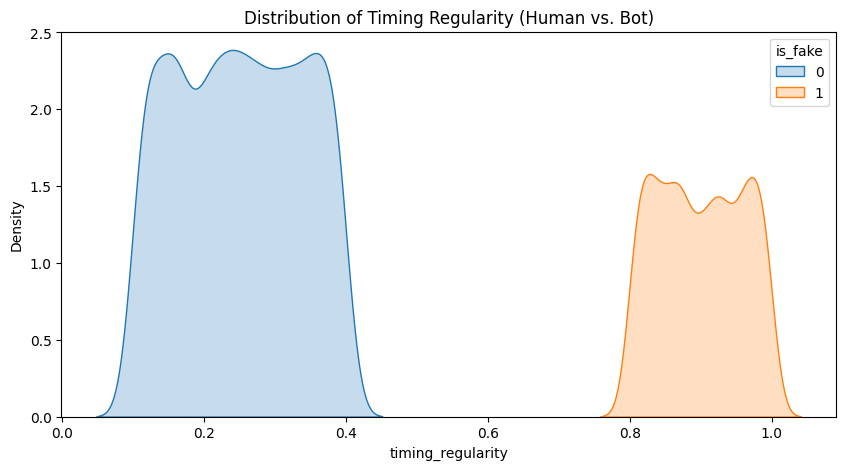

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# FIX: Added numeric_only=True to ignore the user_id strings
behavioral_summary = df.groupby('is_fake').mean(numeric_only=True)

print("Average Behavioral Metrics by Class (0 = Human, 1 = Bot):")
display(behavioral_summary)

# Visualizing the distribution of Timing Regularity
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='timing_regularity', hue='is_fake', fill=True)
plt.title('Distribution of Timing Regularity (Human vs. Bot)')
plt.show()

2. Behavioral Detection Model

We use a Random Forest Classifier to differentiate between organic and artificial engagement. This model is ideal because it allows us to extract "Feature Importance," which explains why a certain account was flagged as a bot.

Expected Outputs:
* Bot Probability: A value between 0 and 1.
* Authenticity Score: A 0-100 scale where 100 is perfectly organic.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Prepare Data
# Dropping user_id because it's just a label, and is_fake because it's the answer
X = df.drop(['user_id', 'is_fake'], axis=1)
y = df['is_fake']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Generate Evaluation
y_pred = model.predict(X_test)
print("Model Performance Report:")
print(classification_report(y_test, y_pred))

Model Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       695
           1       1.00      1.00      1.00       305

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



3. Final Behavioral Insights

This section generates the specific outputs required by the hackathon: the Authenticity Score and the Behavioral Anomaly Explanation.
* Anomaly Explanation: This identifies the primary behavioral trigger (e.g., "High Timing Regularity") that influenced the bot prediction.

In [7]:
# Create a results dataframe for the test set
results = X_test.copy()
probs = model.predict_proba(X_test)[:, 1]

results['Bot_Probability'] = probs
results['Authenticity_Score'] = (1 - probs) * 100

# Function to explain the primary trigger for bots
def get_anomaly_explanation(row):
    if row['Bot_Probability'] < 0.5:
        return "Normal organic behavior"

    # Identify which feature was highest relative to average
    features = ['timing_regularity', 'burst_pattern_score', 'network_coordination_index']
    top_trigger = row[features].idxmax()
    return f"High {top_trigger.replace('_', ' ')} detected"

results['Behavioral_Explanation'] = results.apply(get_anomaly_explanation, axis=1)

# Display final formatted output
print("Final Output for Submission:")
display(results[['Authenticity_Score', 'Bot_Probability', 'Behavioral_Explanation']].head(10))

Final Output for Submission:


,Authenticity_Score,Bot_Probability,Behavioral_Explanation
1501,100.0,0.0,Normal organic behavior
2586,100.0,0.0,Normal organic behavior
2653,100.0,0.0,Normal organic behavior
1055,100.0,0.0,Normal organic behavior
705,0.0,1.0,High burst pattern score detected
106,100.0,0.0,Normal organic behavior
589,0.0,1.0,High network coordination index detected
2468,100.0,0.0,Normal organic behavior
2413,0.0,1.0,High burst pattern score detected
1600,100.0,0.0,Normal organic behavior


4. Behavioural Analytics Dashboard

To provide deeper insights, this dashboard visualizes:
* Feature Importance: Which behavioural indicators (Timing, Bursts, etc.) most influenced the model's decision.

Authenticity vs. Bot Probability: A clear comparison of how the model scores users.

Behavioural Clusters: A 2D representation of how bots and humans separate based on their activity patterns.

/tmp/ipython-input-747/3498672477.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Importance', y='Feature', data=feat_df, palette='viridis')


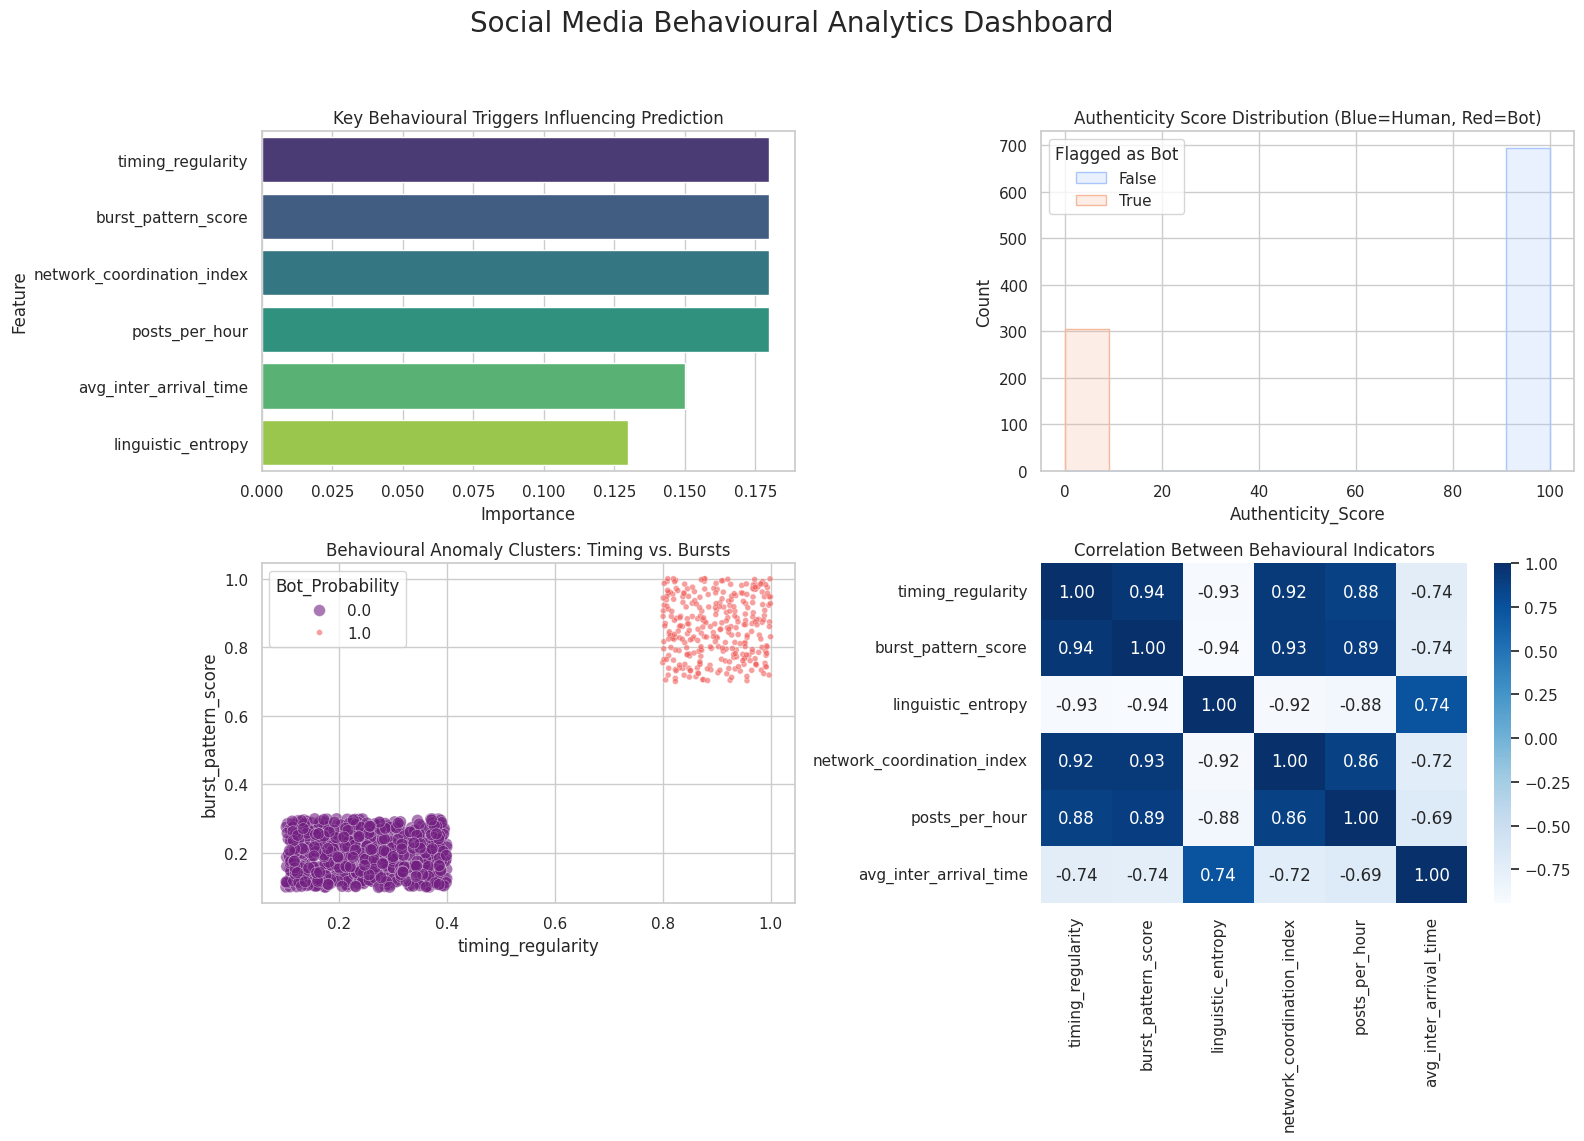

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Social Media Behavioural Analytics Dashboard', fontsize=20)

# 1. Feature Importance Chart
importances = model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

sns.barplot(ax=axes[0, 0], x='Importance', y='Feature', data=feat_df, palette='viridis')
axes[0, 0].set_title('Key Behavioural Triggers Influencing Prediction')

# 2. Authenticity Score Distribution
sns.histplot(ax=axes[0, 1], data=results, x='Authenticity_Score', hue=(results['Bot_Probability'] > 0.5),
             kde=True, element="step", palette='coolwarm')
axes[0, 1].set_title('Authenticity Score Distribution (Blue=Human, Red=Bot)')
axes[0, 1].get_legend().set_title("Flagged as Bot")

# 3. Timing Regularity vs. Burst Patterns (Behavioural Clustering)
sns.scatterplot(ax=axes[1, 0], data=results, x='timing_regularity', y='burst_pattern_score',
                hue='Bot_Probability', size='Bot_Probability', palette='magma', alpha=0.6)
axes[1, 0].set_title('Behavioural Anomaly Clusters: Timing vs. Bursts')

# 4. Correlation Heatmap
sns.heatmap(ax=axes[1, 1], data=X.corr(), annot=True, cmap='Blues', fmt='.2f')
axes[1, 1].set_title('Correlation Between Behavioural Indicators')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()